In [1]:
import os
import gc

import math
import numpy as np
from numpy.random import randint, uniform
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from functools import partial
from joblib import Parallel, delayed

from astropy import units as u

import healpy as hp
import camb

from ksw import Cosmology, Data
from ksw.radial_functional import radial_func

import h5py
from tqdm.auto import tqdm
from pixell import enmap, lensing, curvedsky

import tempfile

%matplotlib inline

The code supports using slurm job arrays to speed up computation due to the memory requirements of the data generation process.

It is recommened to use job arrays for any dataset with more than 10 sims due to time saving. Once run you will want to use the `combiner.ipynb` notebook to combine the data into a single file for training.

In [2]:
# you can include SLURM_ARRAY_JOB_ID if need a unique id for each simulation array, every job in the array will have the same value
job_array_index = os.environ.get('SLURM_ARRAY_TASK_ID')

if job_array_index is not None:
    print('Running job array index', job_array_index)

In [3]:
import time
from psutil import Process
from threading import Thread

class MemoryMonitor(Thread):
    """Monitor the memory usage in MB in a separate thread.

    Note that this class is good enough to highlight the memory profile of
    Parallel in this example, but is not a general purpose profiler fit for
    all cases.
    """
    def __init__(self):
        super().__init__()
        self.stop = False
        self.memory_buffer = []
        self.start()

    def get_memory(self):
        "Get memory of a process and its children."
        p = Process()
        memory = p.memory_info().rss
        for c in p.children():
            memory += c.memory_info().rss
        return memory

    def run(self):
        memory_start = self.get_memory()
        while not self.stop:
            self.memory_buffer.append(self.get_memory() - memory_start)
            time.sleep(0.2)

    def join(self):
        self.stop = True
        super().join()

    def join_and_plot(self, save_name=None):
        self.join()
        peak = max(self.memory_buffer) / 1e9
        print(f"Peak memory usage: {peak:.2f}GB")
        plt.figure()
        plt.title(f"Peak memory usage: {peak:.2f}GB")

        plt.semilogy(
            np.maximum.accumulate(self.memory_buffer),
        )
        plt.xlabel("Time")
        plt.xticks([], [])
        plt.ylabel("Memory usage")
        plt.yticks([1e9, 1e10, 1e11, 1e12], ['1GB', '10GB', '100GB', '1TB'])
        plt.show()
        if save_name is not None:
            save_plt(save_name)

# Data Generator

This code primamrly uses [KSW](https://github.com/AdriJD/ksw/tree/master/src), as a means to generate non-gaussian cmb maps. These get stored in a data file with the fnls, and patches.

The fullsky maps are generated using the method discussed in [CMB lensing and primordial non-Gaussianity](https://arxiv.org/abs/0905.4732), where we find (eq. 6) 
$$
a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}
$$
and generated the full sky map from the $a_{\ell m}$.

Most of this code is to calculate the term (eq. 27)

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

and

$$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$$

$$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$$

$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

where $\Delta_\phi$ is pridormial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions

---

## Settings

See: https://camb.readthedocs.io/en/latest/model.html

Some values are forced during init of ksw.Cosmology. 
For an example on how to modify these values after init: https://github.com/AdriJD/ksw/blob/fba3250cfe4c5145b5db12fa54bbc54bbcf5a56c/tests/python/test_cosmology.py#L65

In [4]:
cosmo_params = {
    'H0': 67.5,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'pivot_scalar': 0.05,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'mnu': 0.06,
    'tau': 0.0561,
    'TCMB': 2.7255,

    'max_l': 3000,
    'lmax': 2000,
    'lens_potential_accuracy': 2,

    ## These are forced by ksw
    "DoLateRadTruncation": False,
    "AccuracyBoost":2.,
    # "BessIntBoost": 30.,
    # "KmaxBoost": 3.,
    # "IntTolBoost": 4.,
    # "TimeStepBoost": 4.,
    # "SourcekAccuracyBoost": 5.,
    # "BesselBoost": 5.,
    # "IntkAccuracyBoost": 5.,
    "lSampleBoost": 2.,
    "lAccuracyBoost": 2.,
    # "AccurateBB": True,
}
lmax=cosmo_params['lmax']

camb_params_obj = camb.set_params(**cosmo_params)
print(camb_params_obj)

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_lens
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 3000
 max_l_tensor = 600
 max_eta_k = 36000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.02233
 omch2 = 0.1198
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.5
 TCMB = 2.7255
 YHe = 0.2458384128277519
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.9624
   nr

`lmax`` >= 300 is enforced by the ksw code due to errors with CAMB. 
`lmax` needs to be somewhat smaller then `max_l`, if you get errors about c_ell change these.

You will get warning messages if `lmax` > 4\* `nside`.  

`nside` should be of type $2^n$.

`num_patches` should be even.

`patch_side_deg` \* `num_patches` \<\= 180, patch_side_deg \<\= 45; or you will overlap patches 

KSW only supports `polarizations` values of 'T', 'E', ['T', 'E']. Currently only T is tested by this code.

In [5]:
fnl_range=(-1000, 1000)

nsims = 1                    # currently nsims % save_size === 0
npatches = 10                # number of patches to generate per sim

nside=1024

patch_side_deg = 10

# valid values 'T', 'E', ['T', 'E']
polarizations = ['T'] #, 'E']

disable_noise = True

noise_loc = 0

noise_scale_tt = 43 * u.arcmin # in uK * arcmin # type: ignore

## TODO find correct noise levels, 143 hz
noise_scale_ee = 4.3 * u.arcmin  # type: ignore
noise_scale_te = .43 * u.arcmin  # type: ignore

beam_width = 7.1 * u.arcmin # type: ignore

batch_size = 1200               # Just helps control memory for the alm_ng calculations
nthreads_alm = 50                # controls overall memeory usage, -1 is all available
nthreads_sim = 5

do_lensing = True

force_alm_gen = True 

# For easy switching between notebook and slurm, just disables plots
debug = True
save_plots = False


In [6]:
# simplest way to prevent issues with alms
# TODO: be smarter about this
if job_array_index is not None:
    force_alm_gen = True

    # to prevent needless image spam we only save every 100th plots
    # if save_plots is false above this will do nothing
    if job_array_index % 100 != 1:
        save_plots = False
    # debug = False

In [7]:
npol = 1 if isinstance(polarizations, str) else len(polarizations)

nell = lmax + 1
nelem = hp.Alm.getsize(lmax)
npix = hp.nside2npix(nside)
ells = np.arange(nell)

alm_ls, alm_ms = hp.Alm.getlm(lmax)

if isinstance(polarizations, str):
    chars_of_polarizations = polarizations
elif isinstance(polarizations, list):
    chars_of_polarizations = ''.join(polarizations)
else:
    raise TypeError("polarizations must be either a string or a list of strings")

We set the file name best on settings, this will let us load in the data better and ensure we know what settings we are dealing with

In [8]:
base_dir = f'data/ksw'
data_dir = base_dir + ('/lensed' if lensing else '/unlensed')
plot_dir = f'{data_dir}/plots/'
alm_cache_dir = f'{base_dir}/alm_cache'

In [9]:
if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
else:
    print(f'Reusing directory {data_dir}')

if not os.path.exists(plot_dir): 
    os.makedirs(plot_dir)

if not os.path.exists(alm_cache_dir): 
    os.makedirs(alm_cache_dir)
    print(f'Created cache directory {alm_cache_dir}')

Reusing directory data/ksw/lensed


In [10]:
def load_data(data_file, key):
    print('Loading data',key,'from',data_file)
    with h5py.File(data_file, 'r') as hdf:
        return np.array(hdf.get(key)[()]) # type: ignore

base_name = f'{nside}_{chars_of_polarizations}_{nsims}'
ja_str = '' if job_array_index is None else f'_{job_array_index}'
nn_str = '-nn' if disable_noise else ''

alm_str = f'{base_name}{ja_str}'
data_str = f'{base_name}x{npatches}{nn_str}_fnl{fnl_range[0]}-{fnl_range[1]}{ja_str}'

alm_file = os.path.join(alm_cache_dir, f'{alm_str}.alms.hdf5.nc')
alm_final_file = os.path.join(alm_cache_dir, f'{alm_str}.alms.hdf5')

almng_file = os.path.join(alm_cache_dir, f'{alm_str}.alms_ng.hdf5.nc')
almng_final_file = os.path.join(alm_cache_dir, f'{alm_str}.alms_ng.hdf5')

data_file = os.path.join(data_dir, f'{data_str}.hdf5.nc')
data_final_file = os.path.join(data_dir, f'{data_str}.hdf5')


In [11]:
if os.path.isfile(alm_file):
    print('removing existing incomplete alm file', alm_file)
    os.remove(alm_file)

if os.path.isfile(almng_file):
    print('removing existing incomplete alm_ng file', almng_file)
    os.remove(almng_file)

if os.path.isfile(data_file):
    print('removing existing incomplete data file', data_file)
    os.remove(data_file)

removing existing incomplete alm file data/ksw/alm_cache/1024_T_1.alms.hdf5.nc


In [12]:
# Check if we need to generate alms, load in alms if we can        
if not force_alm_gen and os.path.isfile(alm_final_file) and os.path.isfile(almng_final_file):
    print('Found existing alms, using them')
    alms = load_data(alm_final_file, 'alm')
    almngs = load_data(almng_final_file, 'almng')
    gen_alms = False
    
    print('alms loaded', alms.shape)
    print('alm_ng loaded', almngs.shape)
else:
    print('Generating new alms')
    alms = None
    almngs = None
    gen_alms = True

Generating new alms


# $a_{\ell m}$ Calculation

In [13]:
# Setup noise and beams

beam_ell_pre = hp.gauss_beam(beam_width.to_value(u.radian), lmax=lmax, pol=True)
beam_ell_pre = np.swapaxes(beam_ell_pre, 0, 1)

noise_ell = []
beam_ell = []
if 'T' in polarizations:
    noise = np.ones((nell)) * noise_scale_tt.to_value(u.radian)**2

    noise_ell.append(noise)
    beam_ell.append(beam_ell_pre[0])

if 'E' in polarizations:
    noise = np.ones((nell)) * noise_scale_ee.to_value(u.radian)**2

    noise_ell.append(noise)
    beam_ell.append(beam_ell_pre[1])
    
if polarizations == ['T', 'E']:
    noise = np.ones((nell)) * noise_scale_te.to_value(u.radian)**2
    noise_ell.append(noise)

noise_ell = np.array(noise_ell).squeeze()
beam_ell = np.array(beam_ell).squeeze()

if disable_noise:
    noise_ell = noise_ell * 10**-12
    beam_ell = np.ones_like(beam_ell)
    
print('noise_ell', noise_ell.shape)
print('beam_ell', beam_ell.shape)

noise_ell (2001,)
beam_ell (2001,)


For the radii we follow Table 2. of Smith and Zaldarriaga which gives a greater density of points near reionization and recombination. 

Spacing for all ranges but the last row are linear, with the last row having log spacing.

radii are in Mpc

In [14]:
r_min = 1                    # Mpc, min radius for the patch     
r_max = 50000                # Mpc, max radius for the patch

radii = []
#          start,  stop, resolution
ranges = [(    0,  9500, 150), 
          ( 9500, 11000, 300), 
          (11000, 13800, 150), 
          (13800, 14600, 400), 
          (14600, 16000, 100), 
          (16000, 50000, 100)]

for r in ranges:
    start = max(r_min, r[0])
    end = min(r_max, r[1])

    if start > end:
        continue

    if r == ranges[-1]: # For the last range, use logspace
        temp_radii = np.logspace(np.log10(start), np.log10(end), num=r[2])
    else:
        temp_radii = np.linspace(start, end, num=r[2], endpoint=False)

    radii.extend(temp_radii)

radii = np.array([r for r in radii if r_min <= r < r_max])
drs = np.diff(radii)

In [15]:
cosmo = Cosmology(camb_params_obj, verbose=True)

# Additional settings here, i.e.
# cosmo._setattr_camb('ns', 0.9624, subclass='InitPower')

cosmo.compute_transfer(cosmo_params['max_l'])
cosmo.compute_c_ell()

data = Data(lmax, noise_ell, beam_ell, polarizations, cosmo)

c_ells = data.cosmology.c_ell['unlensed_scalar'] # type: ignore

tr_ell_k = data.cosmology.transfer['tr_ell_k']
tr_ells = data.cosmology.transfer['ells']
tr_k = data.cosmology.transfer['k']

mask = (tr_ells <= lmax)
tr_ell_k = tr_ell_k[mask]
tr_ells = tr_ells[mask]

Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: AccurateBB from False to True.


In [16]:
if debug:
    noise_ell_b = np.array([noise_scale_tt.to_value(u.radian)**2 * np.exp( (l*(l+1) * beam_width.to_value(u.radian)**2) / (8*np.log(2)) ) for l in range(nell)])
    camb_cls_n = c_ells['c_ell'][2:lmax] + noise_ell_b[2:lmax, np.newaxis]
    camb_ls = np.arange(2, lmax)

    # TODO: suport for T vs E
    camb_inner_plt = camb_ls * (camb_ls + 1) / 2 / np.pi * c_ells['c_ell'][2:lmax][:, 0]
    camb_n_inner_plt = camb_ls * (camb_ls + 1) / 2 / np.pi * camb_cls_n[:, 0]

def plot_cl(cl, 
               plt_func=plt.semilogy,
               plt_camb=True,
               title='Angular power spectrum from cl',
               label='data',
               save_name=None):
    
    if not debug: return
    
    # plt.figure()

    ell = np.arange(len(cl))
    plt_func(ell[2:], (ell * (ell + 1) / 2 / np.pi)[2:] * cl[2:], label=label)

    if plt_camb:
        plt_func(camb_ls, camb_inner_plt, label='camb')
        plt_func(camb_ls, camb_n_inner_plt, label='camb + noise')

    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$\ell(\ell+1)/2\pi C_{\ell}$")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

    if save_name is not None:
        save_plt(save_name)

def plot_cl_alm(alm, plt_func=plt.semilogy, plt_camb=True, title='Angular power spectrum from alm', save_name=None):
    if not debug: return

    cl = curvedsky.alm2cl(alm)
    plot_cl(cl, plt_func, plt_camb, title, save_name)

def plot_cl_map(map, wcs, plt_func=plt.semilogy, plt_camb=True, title='Angular power spectrum from map', save_name=None):
    if not debug: return
    
    tmap = enmap.ndmap(map, wcs)
    almsd = curvedsky.map2alm(tmap, lmax=lmax)
    cl = curvedsky.alm2cl(almsd)
    plot_cl(cl, plt_func, plt_camb, title, save_name)

starttime = time.time()
def save_plt(name):
    if not save_plots: return

    file = f'{plot_dir}/{starttime}-{name}.png'
    plt.savefig(file)

`radial_func` computes $f_\ell^X(r) = \frac{2}{\pi} \int k^2 dk f(k) \Delta^{TX}_\ell(k) j_\ell(k r)$, we will use this to find 
$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$,
and
$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$. 

$\Delta_\ell^T(k)$, the transfer functions, are calculated sparsely (in l) by CAMB; We thus need to interpolate over the missing values to get `alpha_l`, `beta_l` which are suitable for the calculations. 
We do this with `CubicSpline`, but this could be changed if needed. 

We also go ahead and calculate `bl_div_cl`=$\beta_\ell / C_\ell$, which is used to calculate $B(r,\hat{n})$.

In [17]:
if gen_alms:
    def interpolate_ells(func, ells_sparse, ls, axis=1):
        return CubicSpline(ells_sparse, func, axis)(ls)

    delta_phi = (2 * np.pi) * cosmo_params['As'] * np.sqrt(3 / 5)

    f_k = np.ones((len(tr_k), 2), dtype=float)
    # f_k[:, 0] = 1                           # f_k for alpha
    f_k[:, 1] = tr_k**-3 * delta_phi          # f_k for beta

    rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

    alpha_ell = rad[:,:,:,0]
    alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, ells)]))
    alpha_l = np.ascontiguousarray(alpha_l)

    beta_ell = rad[:,:,:,1]
    c_ells_new = c_ells['c_ell'][tr_ells, :npol]
    div = beta_ell / c_ells_new[np.newaxis, :, :]

    bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, ells)]))
    bl_div_cl = np.ascontiguousarray(bl_div_cl)

In [18]:
def save_data(file_path, data_dict, write_mode='a'):
    with h5py.File(file_path, write_mode) as hf:
        for key, value in data_dict.items():
            if key in hf:
                # Resize the dataset to accommodate the new data
                hf[key].resize((hf[key].shape[0] + value.shape[0],) + value.shape[1:]) # type: ignore
                # Append the new data
                hf[key][-value.shape[0]:] = value # type: ignore
            else:
                # Create a new dataset for this key with compression options
                hf.create_dataset(key, data=value, maxshape=(None,) + value.shape[1:])

a_lm progress:   0%|          | 0/1 [00:00<?, ?it/s]

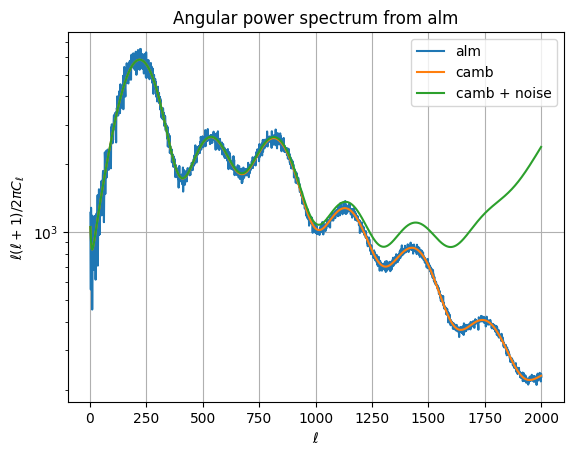

In [19]:
if gen_alms:
    # Each alm takes ~30Mb at 1024. This is fast enought we don't need to parallelize even for very large datasets
    alms = np.array([data.compute_alm_sim(False) for _ in tqdm(range(nsims), desc='a_lm progress')])

    # Make sure we dont get error from the beam_ell being a vector
    beam_ell_2d = np.atleast_2d(beam_ell)

    # KSW expects the alms to be coevoled with the beam
    # for i in range(nsims):
    #     for j in range(npol):
    #         alms[i, j] = hp.almxfl(alms[i, j], beam_ell_2d[j]**-1)

    save_data(alm_file, {'alm': alms})
    plot_cl_alm(alms[0, 0], save_name='alm')

In [20]:
def get_alm(alm, bl_div_cl, alpha_l, r, dr):
    Balm = hp.almxfl(alm, bl_div_cl)
    B = hp.alm2map(Balm, nside=nside, lmax=lmax, pol=False)
    inner = hp.map2alm(B**2, lmax=lmax, pol=False, use_pixel_weights=True)
    kernel = hp.almxfl(inner, alpha_l)
    return dr * r**2 * kernel

if gen_alms:
    if debug:
        monitor = MemoryMonitor()

    # m3's /tmp only has 500gb of storage which was causing issues
    # set dir to something on /scracth
    with tempfile.TemporaryDirectory(dir='data/tmp') as tempdir:
        with Parallel(nthreads_alm, verbose=0, temp_folder=tempdir) as parallel:
            n_batches = math.ceil(len(radii) / batch_size)
            
            for i in tqdm(range(nsims), total=nsims, desc='almng progress'):
                almngs = np.zeros((npol, nelem), dtype=complex)

                for pol in range(npol):
                    for batch_num in range(n_batches):
                        start_index = batch_num * batch_size
                        end_index = min((batch_num + 1) * batch_size, len(drs))
                        
                        batch_radii = radii[start_index:end_index]
                        batch_drs = drs[start_index:end_index]
                        
                        almngs[pol] += np.sum(parallel(
                                delayed(get_alm)(
                                    alms[i, pol], 
                                    bl_div_cl[ri, :, pol], 
                                    alpha_l[ri, :, pol], 
                                    batch_radii[ri], 
                                    batch_drs[ri]) 
                                for ri in range(len(batch_drs))
                            ), # type: ignore
                            axis = 0
                        )
                # TODO: Allow setting save interval
                save_data(almng_file, {'almng': np.array([almngs])}, write_mode='a')

        print(almngs.shape)
        plot_cl_alm(almngs[0], save_name='almng')



almng progress:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
if gen_alms and debug:
    monitor.join_and_plot('alm_memory')

In [ ]:
def rename_save(old, new):
    os.replace(old, new)

In [ ]:
if gen_alms:
    rename_save(alm_file, alm_final_file)
    rename_save(almng_file, almng_final_file)

In [ ]:
gc.collect() # Just force a garbage collection to free up memory

# Sims

In [ ]:
# Just load everything into memory right now, shouldn't be much of a problem until >10k sims
alms = load_data(alm_final_file, 'alm')
almngs = load_data(almng_final_file, 'almng')

print(alms.shape)
print(almngs.shape)

In [ ]:
res = np.deg2rad(patch_side_deg / nside) # TODO Look into better value for res
fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
fs_map = enmap.empty(fs_shape, fs_wcs)

ps_rad = np.deg2rad(patch_side_deg)

patch_shapes = []
patch_wcss = []
for counter in np.arange(npatches//2):
    # [[dec_min,ra_min],[dec_max,ra_max]]
    top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
    s,w = enmap.geometry(pos=top, res=res, proj="car")
    patch_shapes.append(s)
    patch_wcss.append(w)

    bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
    s, w = enmap.geometry(pos=bottom, res=res, proj="car")
    patch_shapes.append(s)
    patch_wcss.append(w)

In [ ]:
def cutSqPatches_pixell(do_lensing, fs_shape, fs_wcs, fs_map, pshapes, pwcs, cl_phi, alm, fnl, alm_ng):
    alms = alm + fnl * alm_ng
    
    fs_map = enmap.empty(fs_shape, fs_wcs)
    car_map = curvedsky.alm2map(alms, fs_map)

    if do_lensing:
        phi_map = curvedsky.rand_map(fs_shape, fs_wcs, cl_phi)
        grad_phi = enmap.grad(phi_map)
        car_map = lensing.lens_map(car_map, grad_phi)

    patches = []
    for i in range(npatches):
        patch = car_map.project(pshapes[i], pwcs[i]) # type: ignore
        patches.append(patch)
        
    return np.array(patches)

cl_phi = data.cosmology._camb_data.get_lens_potential_cls(lmax, CMB_unit='muK', raw_cl=True)
cutPatches = partial(cutSqPatches_pixell, do_lensing, fs_shape, fs_wcs, fs_map, patch_shapes, patch_wcss, cl_phi[:,0])

if debug:
    monitor = MemoryMonitor()

with tempfile.TemporaryDirectory(dir='data/tmp') as tempdir:
    fnls = uniform(fnl_range[0], fnl_range[1], (nsims,))
    patches = np.array(Parallel(nthreads_sim, verbose=10, temp_folder=tempdir)(
            delayed(cutPatches)(alms[i, pol], fnls[i], almngs[i, pol]) 
            for pol in range(npol) for i in range(nsims)
        )).reshape((nsims, npol, npatches, nside, nside))

In [ ]:
if debug:
    monitor.join_and_plot('patch_memory')

In [ ]:
print('fnls', fnls.shape, fnls)
print('patches', patches.shape)

In [ ]:
sdata = {}
sdata['fnls'] = fnls
sdata['patches'] = np.array(patches)

save_data(data_file, sdata)
rename_save(data_file, data_final_file)

In [ ]:
print('Done with Generation!') 

# Just exit if we dont want the plots
if not debug:
    exit(0)        

---

# Plots

In [ ]:
random_indices = [(randint(nsims), randint(npol), randint(npatches)) for _ in range(10)]

print(random_indices)

In [ ]:
# Compute the grid size
grid_size = math.isqrt(len(random_indices))
if grid_size ** 2 < len(random_indices):
    grid_size += 1

# Create the grid of subplots
fig, axs = plt.subplots(grid_size, grid_size, sharex=True, sharey=True, figsize=(10, 10))

# If there's only one plot, put it in a list within a list to emulate a 2D list
if grid_size == 1:
    axs = [[axs]]

# Iterate over the random_indices
for idx, (i, p, n) in enumerate(random_indices):
    # Compute the subplot coordinates
    row = idx // grid_size
    col = idx % grid_size
    # Plot the image
    axs[row][col].imshow(patches[i, p, n])

# Hide the remaining unused subplots if any
if len(random_indices) < grid_size * grid_size:
    for idx in range(len(random_indices), grid_size * grid_size):
        row = idx // grid_size
        col = idx % grid_size
        axs[row][col].axis('off')

plt.title('Sample Patches')
plt.show()
save_plt('sample_patches')

In [ ]:
for sim, pol, patch in random_indices:
    plot_cl_map(patches[sim, pol, patch], patch_wcss[patch], title='Angular power from patch', save_name=f'cl_patch_{sim}_{pol}_{patch}')

# Goodbye